# Zero-action baseline vs. upper+lower heuristic vs. trained PPO

Compares three controllers across all 7 controllable scenarios (`jain_balance_controllable`, `jain_control_urllc`, `jain_control_mmtc`, `jain_control_embb_urllc`, `jain_control_embb_mmtc`, `jain_control_urllc_mmtc`, `jain_control_mixed`):

1. **Zero-action** -- bias held at 0 the whole episode (default A3, no rebalancing). `results/zero_action_baseline/`
2. **Upper+lower heuristic** -- rule-based `compute_upper_expert_directional_bias` upper controller, executed through the same `strong_directional_heuristic_local_executor` every policy uses. `results/upper_lower_heuristic_baseline/`
3. **Trained PPO** -- checkpoint `models/upper_ppo_single_scenario_tight_std/run_20260702_141129/upper_ppo_best.zip`, evaluated deterministically. `results/trained_ppo_tight_std_eval/`

**Important caveat on (3):** this checkpoint was trained on **`jain_balance_controllable` only** (`--no-curriculum-training --single-training-scenario jain_balance_controllable`), and it's a **mid-training checkpoint** -- the training run (started 2026-07-02 14:11, `--log-std-init -1.0 --paper-handover-penalty-weight 0.5`) was still in progress when this checkpoint was saved. So running it on the other 6 scenarios is an out-of-distribution generalization check, not an apples-to-apples "fully trained" comparison, and even on its own training scenario it may not yet reflect a converged policy.


In [ ]:
import os
from pathlib import Path

# Make this notebook runnable regardless of the kernel's working directory
# (e.g. VSCode/Jupyter often start in notebooks/, not the repo root).
if not Path('results').exists():
    os.chdir(Path.cwd().parent)

import pandas as pd, glob

def load_summary(pattern):
    rows = []
    for f in sorted(glob.glob(pattern)):
        df = pd.read_csv(f)
        scen = df['scenario_name'].iloc[0]
        rows.append({
            'scenario': scen,
            'handover_count': df['handover_count'].mean(),
            'throughput_mbps': df['network_throughput_mbps'].mean(),
            'delivery_ratio': df['network_delivery_ratio'].mean(),
            'jain_fairness_raw': df['jain_fairness_raw'].mean(),
            'sla_severity': df['sla_severity'].mean(),
        })
    return pd.DataFrame(rows).set_index('scenario')

baseline = load_summary('results/zero_action_baseline/*_zero_action_trace.csv')
heuristic = load_summary('results/upper_lower_heuristic_baseline/*_heuristic_trace.csv')
trained = load_summary('results/trained_ppo_tight_std_eval/*_trained_policy_trace.csv')

comparison = pd.concat(
    {'zero_action': baseline, 'heuristic': heuristic, 'trained_ppo': trained},
    axis=1,
)
comparison.round(3)


                             zero_action                                                                    heuristic                                                                  trained_ppo                                                              
                          handover_count throughput_mbps delivery_ratio jain_fairness_raw sla_severity handover_count throughput_mbps delivery_ratio jain_fairness_raw sla_severity handover_count throughput_mbps delivery_ratio jain_fairness_raw sla_severity
scenario                                                                                                                                                                                                                                                        
jain_balance_controllable            0.0          61.634          0.995             0.333        0.000            6.0          74.485          1.000             0.666        0.000            0.0          67.684          0.991    

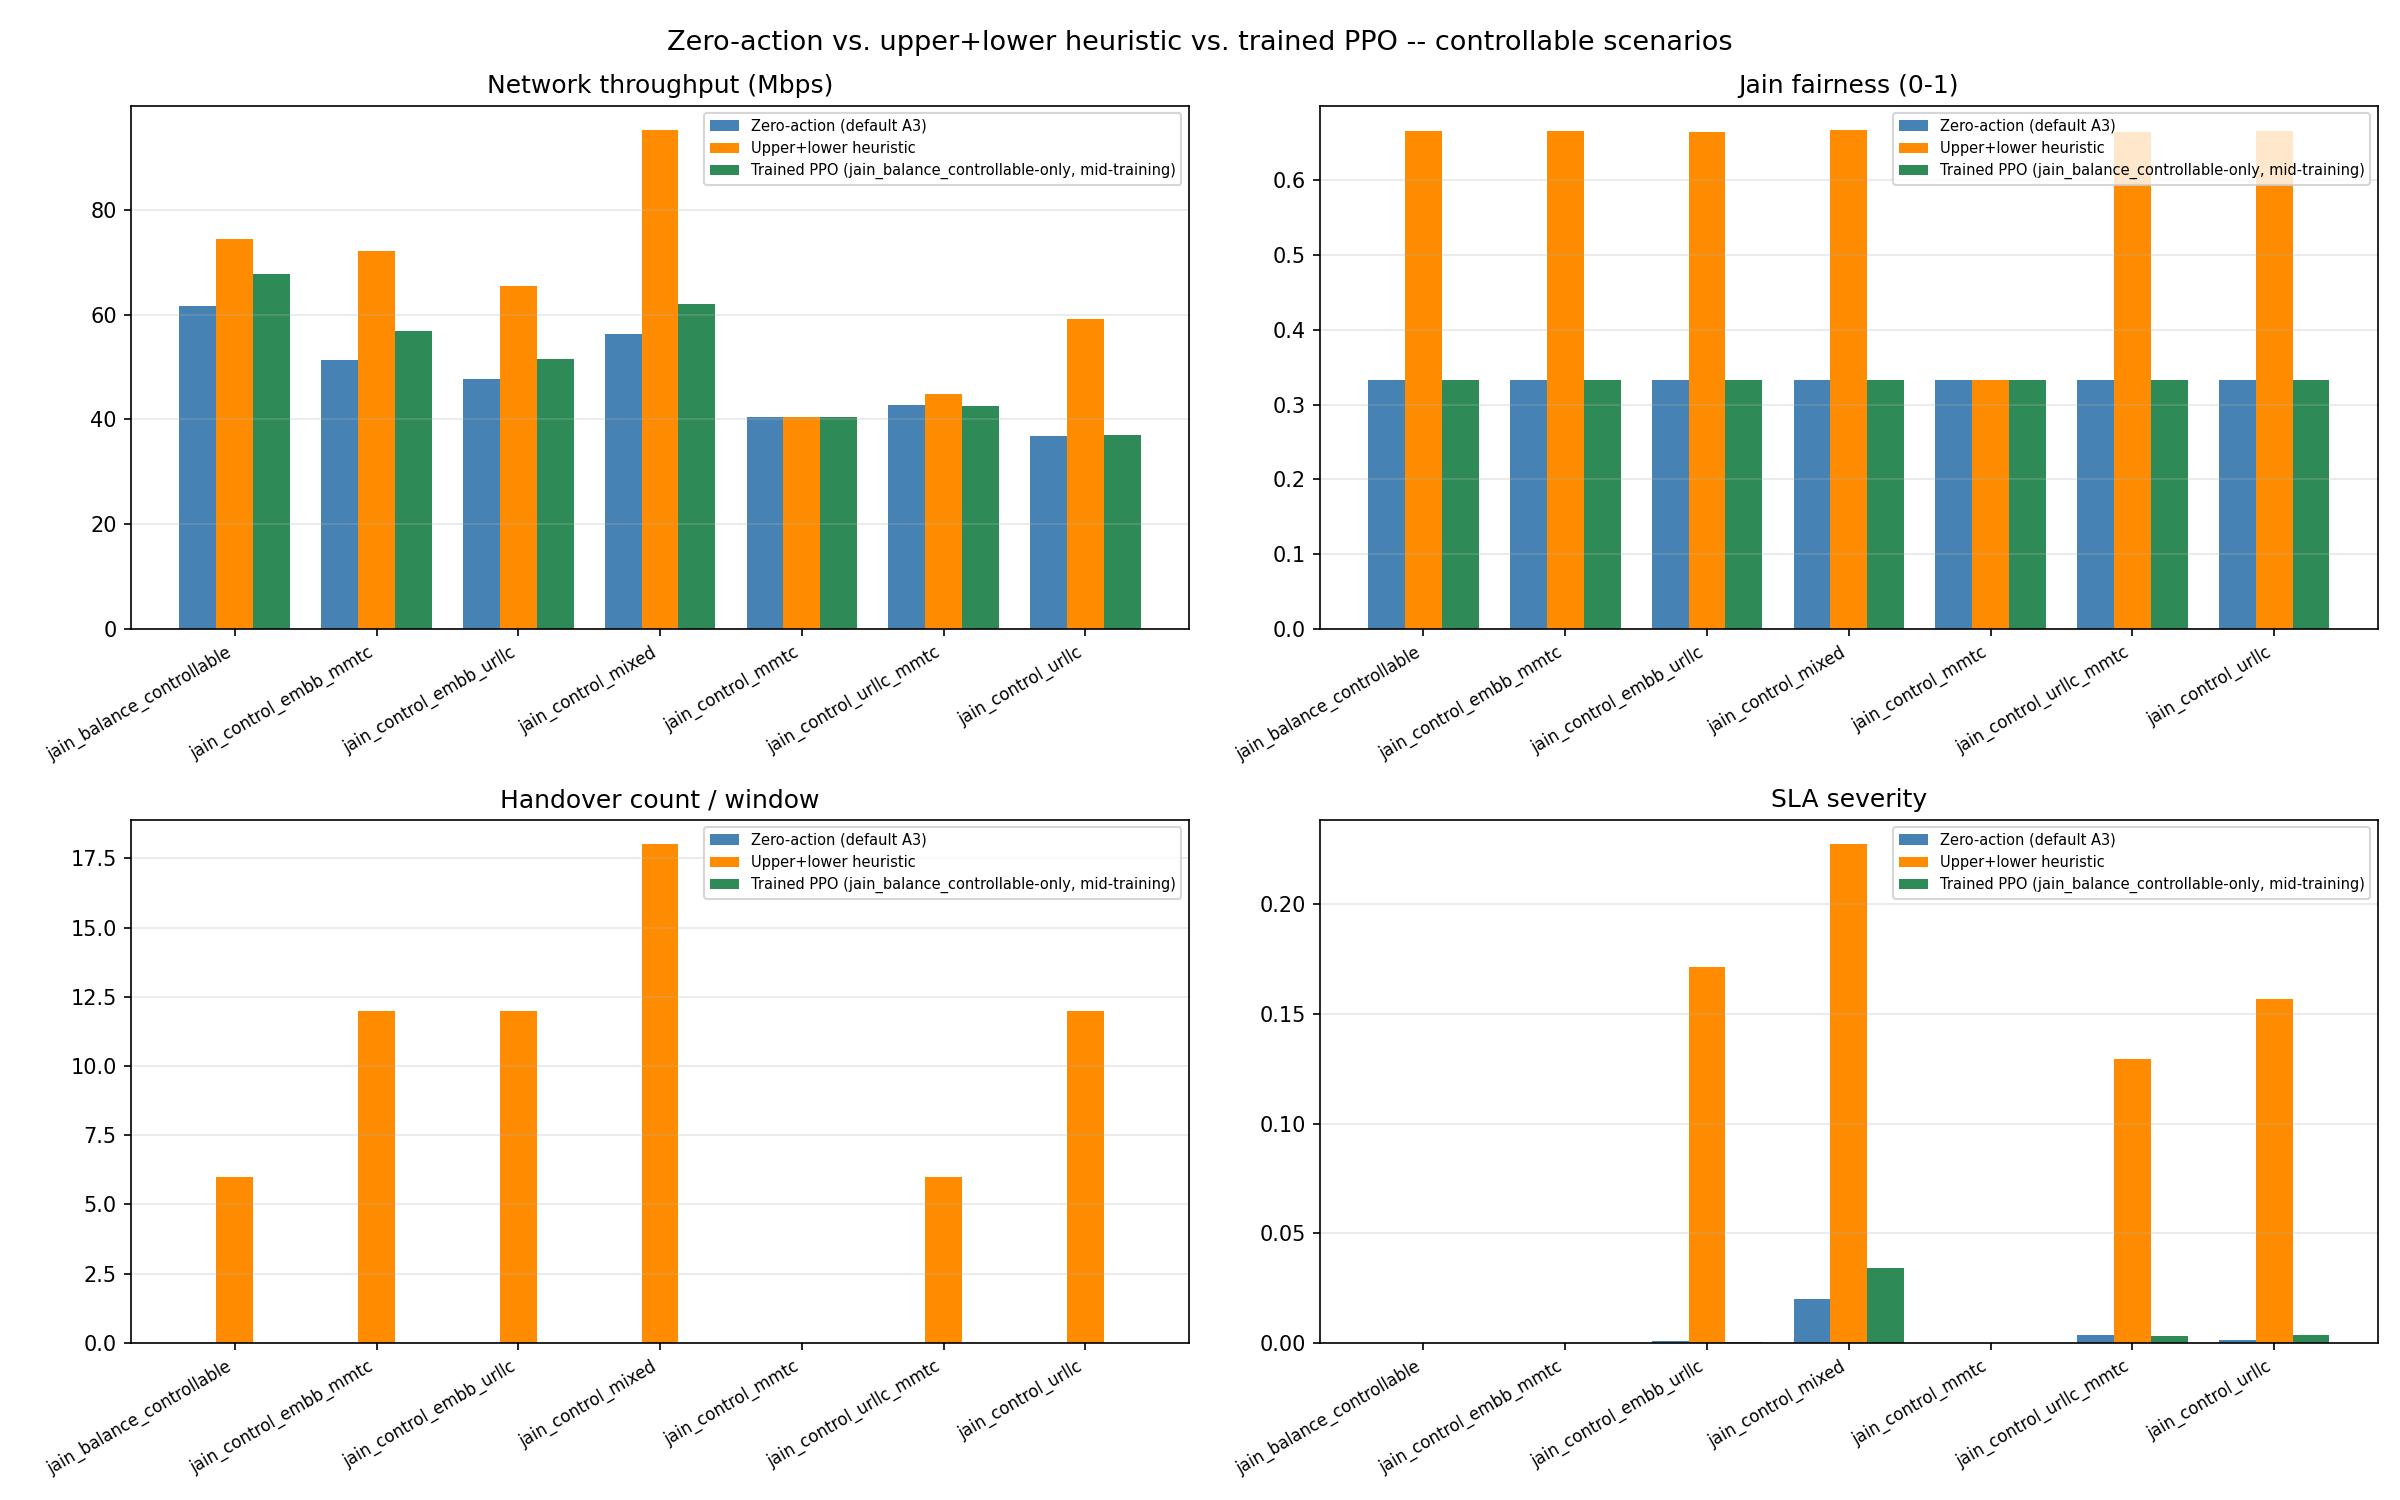

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

scenarios = list(baseline.index)
x = np.arange(len(scenarios))
width = 0.26
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('throughput_mbps', 'Network throughput (Mbps)', axes[0,0]),
    ('jain_fairness_raw', 'Jain fairness (0-1)', axes[0,1]),
    ('handover_count', 'Handover count / window', axes[1,0]),
    ('sla_severity', 'SLA severity', axes[1,1]),
]
colors = {'zero_action': 'steelblue', 'heuristic': 'darkorange', 'trained_ppo': 'seagreen'}
labels = {
    'zero_action': 'Zero-action (default A3)',
    'heuristic': 'Upper+lower heuristic',
    'trained_ppo': 'Trained PPO (jain_balance_controllable-only, mid-training)',
}

for metric, title, ax in metrics:
    for i, name in enumerate(['zero_action', 'heuristic', 'trained_ppo']):
        vals = [baseline, heuristic, trained][i][metric]
        ax.bar(x + (i - 1) * width, vals, width, label=labels[name], color=colors[name])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Zero-action vs. upper+lower heuristic vs. trained PPO -- controllable scenarios', fontsize=13)
fig.tight_layout()
plt.show()


## Findings

- **Zero-action** is the true floor: `handover_count=0` and `jain_fairness_raw=0.333` (all demand stuck on gNB1) in every scenario, by construction.
- **Upper+lower heuristic** clearly rebalances in 6/7 scenarios, lifting Jain fairness to ~0.665 and throughput up meaningfully (e.g. `jain_control_mixed`: 56.3 -> 95.2 Mbps). It's the only one of the three that does anything on `jain_control_mixed`'s SLA-severity front, but that comes with a real SLA cost (severity up to 0.227 there) -- rebalancing isn't free.
- **`jain_control_mmtc` is untouched by the heuristic** (`handover_count=0`, identical to zero-action) -- same anomaly flagged earlier; the rule-based controller's trigger conditions never fire for this scenario's load level on the mMTC slice.
- **The trained PPO checkpoint currently behaves indistinguishably from zero-action** across all 7 scenarios: `handover_count=0` and `jain_fairness_raw=0.333` everywhere, including on `jain_balance_controllable`, the one scenario it was actually trained on. This matches what we already knew from the live training log -- the policy's action std hadn't shrunk meaningfully yet at the point this checkpoint was saved, so its deterministic (mean) action isn't strong enough to cross the A3/admission trigger threshold. This is **not a fair reflection of the upper-agent approach**, just of this specific early checkpoint -- re-run this notebook against a later/final checkpoint once training completes.
